# Question 2: Forward Vol Time Series

Build a panel of forward vols by stripping the cap curve on each date in the time series.

In [ ]:
plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", 15)

DATA_PATH = Path("Data")

In [ ]:
cap_raw = pd.read_excel(DATA_PATH / "project_cap_vol_ts.xlsx", sheet_name="cap", index_col=0)
cap_maturities = cap_raw.loc["maturity"].astype(float)
cap_data = cap_raw.drop(index="maturity").astype(float)
cap_data.index = pd.to_datetime(cap_data.index)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = "maturity"
cap_data = cap_data.T.drop_duplicates().T

sofr_raw = pd.read_excel(DATA_PATH / "project_cap_vol_ts.xlsx", sheet_name="sofr", index_col=0)
sofr_maturities = sofr_raw.loc["maturity"].astype(float)
sofr_data = sofr_raw.drop(index="maturity").astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = "maturity"
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100

curves_val = pd.read_excel(
    DATA_PATH / "cap_curves_2025-06-30.xlsx", sheet_name="rate curves 2025-06-30"
).set_index("tenor")

print(f"Cap data: {cap_data.shape[0]} days, maturities: {list(cap_data.columns)}")
print(f"SOFR data: {sofr_data.shape[0]} days, tenors: {sofr_data.shape[1]}")

Cap data: 989 days, maturities: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
SOFR data: 1033 days, tenors: 21


## Stripping Pipeline

For each date: interpolate to quarterly grid, build discount/forward curves, convert normal vol to Black vol, bootstrap forward vols.

### Pipeline Validation (2025-06-30)

Compare bootstrapped forward vols against the processed validation file.

Bootstrap validation (using validation file data): max error = 7.97e-13


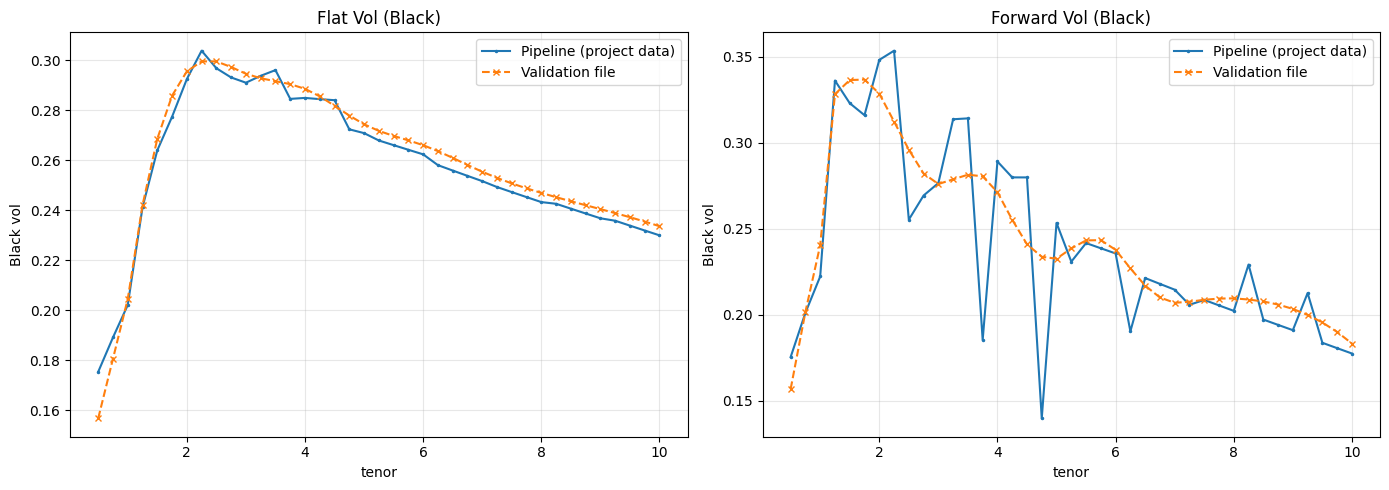


Note: Project data and validation file use different Bloomberg sources,
so flat/fwd vols differ. The bootstrap logic itself is exact (verified above).


In [ ]:
fwd_vols_check = strip_forward_vols(
    curves_val.rename(columns={"swap rates": "swap rates", "fwd vols": "fwd vols_ref"})
)

comp_exact = pd.DataFrame(
    {"bootstrap": fwd_vols_check, "reference": curves_val["fwd vols"]}
).dropna()
print(
    f"Bootstrap validation (using validation file data): max error = {(comp_exact['bootstrap'] - comp_exact['reference']).abs().max():.2e}"
)

curves_test = process_date(pd.Timestamp("2025-06-30"), cap_data, sofr_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
curves_test["flat vols"].dropna().plot(ax=ax, label="Pipeline (project data)", marker=".", ms=3)
curves_val["flat vols"].dropna().plot(
    ax=ax, label="Validation file", marker="x", ms=4, linestyle="--"
)
ax.set_title("Flat Vol (Black)")
ax.set_ylabel("Black vol")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
curves_test["fwd vols"].dropna().plot(ax=ax, label="Pipeline (project data)", marker=".", ms=3)
curves_val["fwd vols"].dropna().plot(
    ax=ax, label="Validation file", marker="x", ms=4, linestyle="--"
)
ax.set_title("Forward Vol (Black)")
ax.set_ylabel("Black vol")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNote: Project data and validation file use different Bloomberg sources,")
print("so flat/fwd vols differ. The bootstrap logic itself is exact (verified above).")

## (a) Weekly Forward Vol Panel

In [ ]:
common_dates = cap_data.dropna(how="any").index.intersection(sofr_data.dropna(how="any").index)
weekly_dates = pd.DatetimeIndex(
    pd.Series(common_dates, index=common_dates).resample("W").last().dropna().values
)
print(
    f"Processing {len(weekly_dates)} weekly dates: {weekly_dates[0].date()} to {weekly_dates[-1].date()}"
)

KEY_TENORS = [0.5, 1.0, 2.0, 3.0, 5.0]

fwd_vol_black = pd.DataFrame(index=weekly_dates, columns=KEY_TENORS, dtype=float)
fwd_vol_normal = pd.DataFrame(index=weekly_dates, columns=KEY_TENORS, dtype=float)

failures = []
for date in weekly_dates:
    try:
        result = process_date(date, cap_data, sofr_data)
        for tenor in KEY_TENORS:
            if tenor in result.index:
                fwd_vol_black.loc[date, tenor] = result.loc[tenor, "fwd_vols"]
                fwd_vol_normal.loc[date, tenor] = (
                    result.loc[tenor, "fwd_vols"] * result.loc[tenor, "forward_rate"] * 10000
                )
    except Exception as e:
        failures.append((date, str(e)))

print(
    f"Successfully processed: {fwd_vol_black.dropna(how='all').shape[0]} / {len(weekly_dates)} weeks"
)
if failures:
    print(f"Failures: {len(failures)}")

fwd_vol_black.columns.name = "tenor"
fwd_vol_normal.columns.name = "tenor"

display(fwd_vol_black.dropna().tail())
display(fwd_vol_normal.dropna().tail())

Processing 199 weekly dates: 2022-03-18 to 2025-12-30
Successfully processed: 199 / 199 weeks


tenor,0.5,1.0,2.0,3.0,5.0
2025-12-04,0.169749,0.169749,0.274308,0.240957,0.203873
2025-12-11,0.165049,0.165049,0.255942,0.230883,0.205831
2025-12-19,0.159510,0.159510,0.248978,0.227297,0.196754
2025-12-24,0.159199,0.159199,0.247749,0.227053,0.198429
2025-12-30,0.161284,0.161284,0.250757,0.224951,0.195791


tenor,0.5,1.0,2.0,3.0,5.0
2025-12-04,60.248471,54.7,86.460079,80.081372,73.903809
2025-12-11,58.340637,53.8,83.524798,79.530420,76.443478
2025-12-19,55.409533,50.7,80.227812,77.813346,73.593253
2025-12-24,55.500023,51.2,80.573653,78.201870,74.532928
2025-12-30,55.781180,50.9,80.481768,77.032914,73.367457


## (b) Forward Vol Dynamics

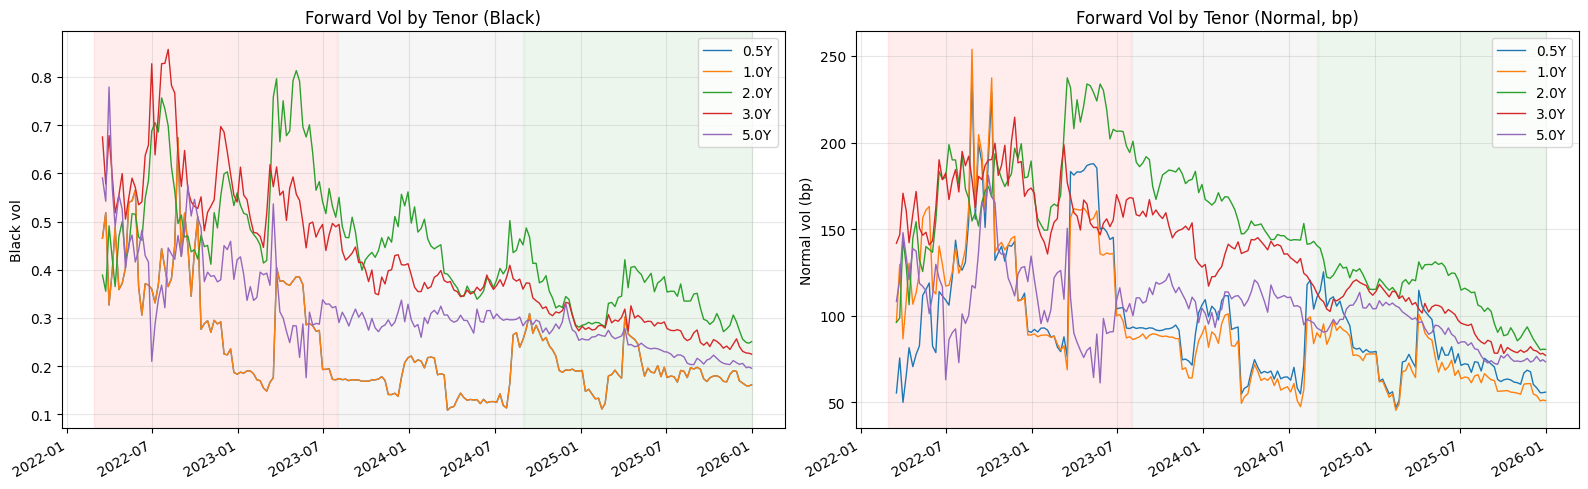

In [ ]:
REGIMES = [
    (pd.Timestamp("2022-03-01"), pd.Timestamp("2023-07-31"), "red", "Hiking"),
    (pd.Timestamp("2023-08-01"), pd.Timestamp("2024-08-31"), "gray", "Pause"),
    (pd.Timestamp("2024-09-01"), pd.Timestamp("2025-12-31"), "green", "Easing"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for tenor in KEY_TENORS:
    fwd_vol_black[tenor].dropna().plot(ax=ax, label=f"{tenor}Y", linewidth=1)
ax.set_title("Forward Vol by Tenor (Black)")
ax.set_ylabel("Black vol")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for tenor in KEY_TENORS:
    fwd_vol_normal[tenor].dropna().plot(ax=ax, label=f"{tenor}Y", linewidth=1)
ax.set_title("Forward Vol by Tenor (Normal, bp)")
ax.set_ylabel("Normal vol (bp)")
ax.legend()
ax.grid(True, alpha=0.3)

for a in axes:
    for start, end, color, label in REGIMES:
        a.axvspan(start, end, alpha=0.07, color=color)

plt.tight_layout()
plt.legend()
plt.show()

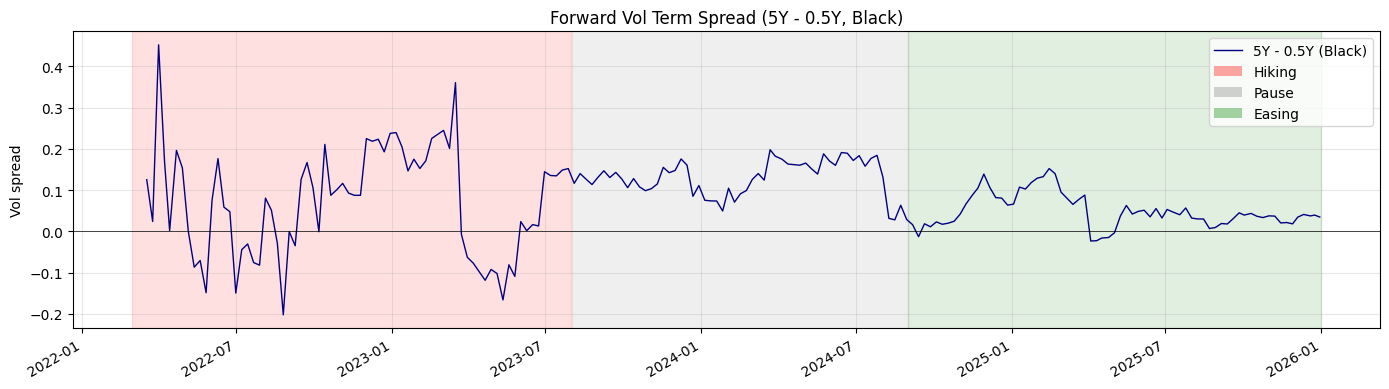

In [ ]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(14, 4))

spread_black = fwd_vol_black[5.0] - fwd_vol_black[0.5]
spread_black.dropna().plot(ax=ax, color="navy", linewidth=1, label="5Y - 0.5Y (Black)")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Forward Vol Term Spread (5Y - 0.5Y, Black)")
ax.set_ylabel("Vol spread")
ax.grid(True, alpha=0.3)

for start, end, color, label in REGIMES:
    ax.axvspan(start, end, alpha=0.12, color=color)


regime_handles = [Patch(facecolor=color, edgecolor="none", alpha=0.35, label=label)
                  for _, _, color, label in REGIMES]

line_handle = plt.Line2D([0], [0], color="navy", lw=1, label="5Y - 0.5Y (Black)")
ax.legend(handles=[line_handle, *regime_handles], loc="upper right")

plt.tight_layout()
plt.show()

**Discussion (Q2b):**

- **Which tenors are most volatile?** Medium term-tenor forward vols (2Y - 3Y) are far more volatile than long-tenor vols and shorter term tenors. From the plot above, we see that 2Y and 3Y forward vols have maintained a black vol of around 30-40%, spiking during the rate hike of 2022-23, while 1Y and 5Y tenored instruments having significantly smaller forward vols, at around 20%-30% black vol. This makes sense since medium tenored caplets experienced a vol hump in the previous exercise, due to the market pricing uncertainty revolving around FOMC meetings. 

- **Hiking (2022--23):** All-tenor forward vols are elevated and became highly volatile, with 2Y and 3Y being the most volatile of all. 3Y black vol peaked at around 80%, and 1Y normal vol peaked at around 250 bps. All forward vols also experienced significant volatility during this period, changing drastically due to Fed policies. The term spread became negative for a few months as well due to the uncertainty.

- **Pause (2023--24):** A sharp regime change. Short-tenor vol collapses sharply as the Fed holds at 5.3% and the near-term rate path becomes predictable. However, 2Y vol remains significantly elevated relative to 0.5Y throughout this period, and the term spread stabilizes firmly positive around +0.10 to +0.20. This reflects the market repricing the timing of cuts rather than the level of rates — uncertainty shifted from "how high" to "how long."

- **Easing (2024--25):** Contrary to what might be expected, the vol term structure compresses rather than steepens. All tenors decline together — 2Y and 3Y converge toward 0.5Y levels — and the term spread collapses near zero by late 2025. This suggests the cutting cycle was well-telegraphed enough that even medium-tenor uncertainty was resolved. The near-zero term spread in early 2025 is notable: the market saw essentially equal uncertainty across the full curve, consistent with a "soft landing" scenario where the terminal rate was fairly well anchored.

## (c) Summary Statistics

In [ ]:
print("Forward Vol Summary Statistics (Normal Vol, bp)")
print("=" * 60)
stats_normal = fwd_vol_normal.describe().loc[["mean", "std", "min", "max", "count"]]
display(stats_normal.round(1))

print()
print("Forward Vol Summary Statistics (Black Vol)")
print("=" * 60)
stats_black = fwd_vol_black.describe().loc[["mean", "std", "min", "max", "count"]]
display(stats_black.round(4))

Forward Vol Summary Statistics (Normal Vol, bp)


tenor,0.5,1.0,2.0,3.0,5.0
mean,96.7,93.4,151.5,136.0,103.7
std,36.4,37.2,37.6,33.0,20.0
min,46.7,45.3,80.2,77.0,61.1
max,240.3,253.8,237.3,214.6,181.0
count,199.0,199.0,199.0,199.0,199.0



Forward Vol Summary Statistics (Black Vol)


tenor,0.5,1.0,2.0,3.0,5.0
mean,0.2355,0.2355,0.4434,0.4190,0.3154
std,0.1051,0.1051,0.1245,0.1413,0.0929
min,0.1086,0.1086,0.2477,0.2250,0.1762
max,0.6736,0.6736,0.8129,0.8569,0.7789
count,199.0000,199.0000,199.0000,199.0000,199.0000


In [ ]:
regimes = fwd_vol_normal.index.map(assign_regime)

print("Mean Forward Normal Vol (bp) by Regime")
print("=" * 60)
regime_means = fwd_vol_normal.groupby(regimes).mean()
display(regime_means.round(1))

Mean Forward Normal Vol (bp) by Regime


tenor,0.5,1.0,2.0,3.0,5.0
Easing,77.1,69.5,112.9,99.4,90.1
Hiking,125.0,129.9,179.2,168.0,112.9
Pause,85.1,76.8,163.9,140.7,108.6


**Discussion (Q2c):**

#### We report in normal vol (bp) for cross-tenor comparison. The choice matters: in Black vol, 0.5Y and 1.0Y appear identical (mean 0.2355) while 2Y peaks at 0.4434, suggesting medium tenors carry the most uncertainty. However in normal vol the picture is more nuanced — 0.5Y averages 96.7 bp vs 2Y at 151.5 bp, but the 0.5Y max (240 bp) nearly matches 2Y's max (237 bp). The discrepancy arises because Black vol scales inversely with the forward rate level, mechanically inflating short-tenor Black vols when forward rates are low. Normal vol removes this level effect, revealing that absolute rate uncertainty was genuinely highest at medium tenors (2Y-3Y) across the full sample.

#### The regime breakdown confirms this: during hiking, vol was elevated across the board (0.5Y = 125 bp, 2Y = 179 bp, 5Y = 113 bp), with 2Y and 3Y carrying the largest absolute uncertainty. During the pause, short-tenor vol collapsed sharply (0.5Y drops to 85 bp, 1Y to 77 bp) while medium-tenor vol remained sticky (2Y = 164 bp, 3Y = 141 bp) — the market had resolved near-term rate levels but not the cutting timeline. During easing, the curve flattens and compresses across all tenors (0.5Y = 77 bp through 5Y = 90 bp), with the term structure becoming nearly flat, consistent with a well-telegraphed cutting cycle reducing uncertainty uniformly. The standard deviation declining from 36 bp at 0.5Y to 20 bp at 5Y confirms that short-tenor policy uncertainty drives the bulk of forward vol variation over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from pathlib import Path
from IPython.display import display

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", 15)

DATA_PATH = Path("Data")

In [10]:
cap_raw = pd.read_excel(DATA_PATH / "project_cap_vol_ts.xlsx", sheet_name="cap", index_col=0)
cap_maturities = cap_raw.loc["maturity"].astype(float)
cap_data = cap_raw.drop(index="maturity").astype(float)
cap_data.index = pd.to_datetime(cap_data.index)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = "maturity"
cap_data = cap_data.T.drop_duplicates().T

sofr_raw = pd.read_excel(DATA_PATH / "project_cap_vol_ts.xlsx", sheet_name="sofr", index_col=0)
sofr_maturities = sofr_raw.loc["maturity"].astype(float)
sofr_data = sofr_raw.drop(index="maturity").astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = "maturity"
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100

curves_val = pd.read_excel(
    DATA_PATH / "cap_curves_2025-06-30.xlsx", sheet_name="rate curves 2025-06-30"
).set_index("tenor")

print(f"Cap data: {cap_data.shape[0]} days, maturities: {list(cap_data.columns)}")
print(f"SOFR data: {sofr_data.shape[0]} days, tenors: {sofr_data.shape[1]}")

Cap data: 989 days, maturities: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
SOFR data: 1033 days, tenors: 21


## Stripping Pipeline

For each date: interpolate to quarterly grid, build discount/forward curves, convert normal vol to Black vol, bootstrap forward vols.

In [3]:
def blacks_formula(T, vol, strike, fwd, discount=1.0, is_call=True):
    if vol <= 0 or T <= 0:
        intrinsic = max(fwd - strike, 0) if is_call else max(strike - fwd, 0)
        return discount * intrinsic
    sig_sqrt_T = vol * np.sqrt(T)
    d1 = (np.log(fwd / strike) + 0.5 * vol**2 * T) / sig_sqrt_T
    d2 = d1 - sig_sqrt_T
    if is_call:
        return discount * (fwd * norm.cdf(d1) - strike * norm.cdf(d2))
    else:
        return discount * (strike * norm.cdf(-d2) - fwd * norm.cdf(-d1))


def build_quarterly_curves(date, cap_data, sofr_data):
    swaps = sofr_data.loc[date].dropna()
    cap_vols_bp = cap_data.loc[date].dropna()

    max_tenor = min(cap_vols_bp.index.max(), swaps.index.max())
    tenors = np.arange(0.25, max_tenor + 0.01, 0.25)
    tenors = np.round(tenors, 2)

    swap_q = pd.Series(
        np.interp(tenors, swaps.index.values, swaps.values), index=tenors, name="swap rates"
    )

    discounts = pd.Series(np.nan, index=tenors, name="discounts")
    for i, T in enumerate(tenors):
        R = swap_q.iloc[i]
        known_sum = discounts.iloc[:i].sum() * 0.25
        discounts.iloc[i] = (1 - R * known_sum) / (1 + R * 0.25)

    forwards = pd.Series(np.nan, index=tenors, name="forwards")
    for i in range(1, len(tenors)):
        forwards.iloc[i] = (discounts.iloc[i - 1] / discounts.iloc[i] - 1) / 0.25

    cap_tenors = cap_vols_bp.index.values
    cap_vals = cap_vols_bp.values
    ext_tenors = np.concatenate([[0.25], cap_tenors[cap_tenors >= 1.0]])
    ext_vals = np.concatenate([[cap_vals[0]], cap_vals[cap_tenors >= 1.0]])
    flat_bp_q = np.interp(tenors, ext_tenors, ext_vals)

    flat_vols_black = pd.Series(flat_bp_q / 10000 / swap_q.values, index=tenors, name="flat vols")
    flat_vols_black[tenors < 0.5] = np.nan

    return pd.DataFrame(
        {
            "swap rates": swap_q,
            "discounts": discounts,
            "forwards": forwards,
            "flat vols": flat_vols_black,
        },
        index=tenors,
    )


def strip_forward_vols(curves, dt=0.25, notional=100):
    tenors = curves.index.values
    flat_vols = curves["flat vols"].values
    swaps = curves["swap rates"].values
    fwds = curves["forwards"].values
    discs = curves["discounts"].values
    n = len(tenors)

    fwd_vols = np.full(n, np.nan)

    first_idx = np.argmin(np.abs(tenors - 0.5))
    fwd_vols[first_idx] = flat_vols[first_idx]

    for i in range(first_idx + 1, n):
        if np.isnan(flat_vols[i]):
            continue

        K = swaps[i]
        sigma_flat = flat_vols[i]

        cap_price = 0.0
        for j in range(first_idx, i + 1):
            fix_t = tenors[j] - dt
            cap_price += notional * dt * blacks_formula(fix_t, sigma_flat, K, fwds[j], discs[j])

        known_sum = 0.0
        for j in range(first_idx, i):
            fix_t = tenors[j] - dt
            known_sum += notional * dt * blacks_formula(fix_t, fwd_vols[j], K, fwds[j], discs[j])

        last_caplet = cap_price - known_sum

        if last_caplet <= 0:
            fwd_vols[i] = fwd_vols[i - 1]
            continue

        fix_t = tenors[i] - dt
        try:
            fwd_vols[i] = brentq(
                lambda vol: (
                    notional * dt * blacks_formula(fix_t, vol, K, fwds[i], discs[i]) - last_caplet
                ),
                1e-6,
                10.0,
            )
        except (ValueError, RuntimeError):
            fwd_vols[i] = fwd_vols[i - 1]

    return pd.Series(fwd_vols, index=tenors, name="fwd vols")


def process_date(date, cap_data, sofr_data):
    curves = build_quarterly_curves(date, cap_data, sofr_data)
    curves["fwd vols"] = strip_forward_vols(curves)
    return curves

### Pipeline Validation (2025-06-30)

Compare bootstrapped forward vols against the processed validation file.

Bootstrap validation (using validation file data): max error = 7.97e-13


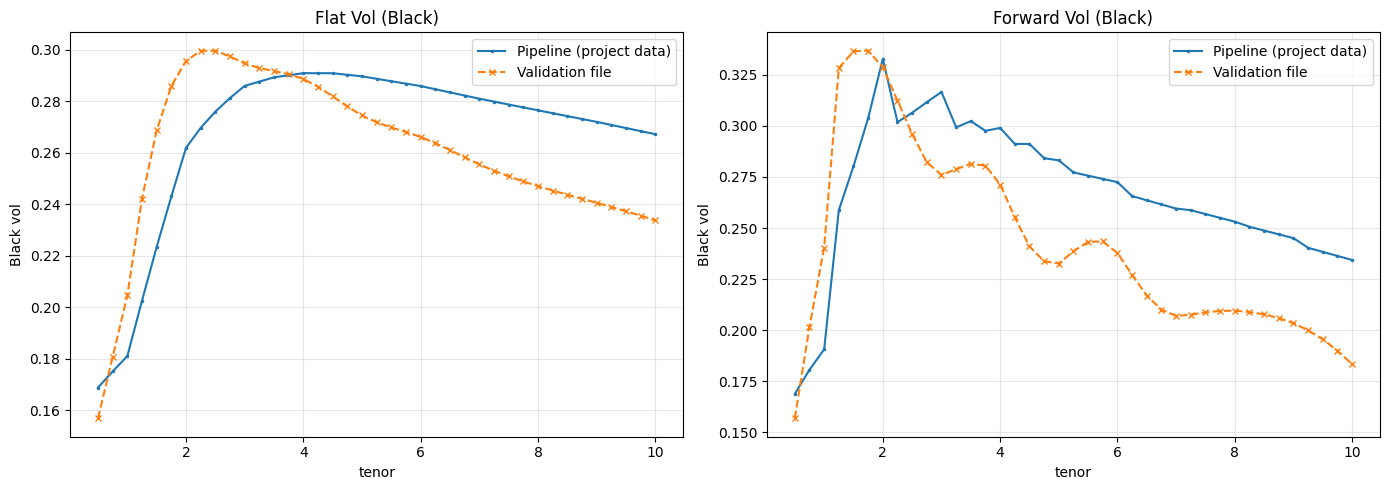


Note: Project data and validation file use different Bloomberg sources,
so flat/fwd vols differ. The bootstrap logic itself is exact (verified above).


In [4]:
fwd_vols_check = strip_forward_vols(
    curves_val.rename(columns={"swap rates": "swap rates", "fwd vols": "fwd vols_ref"})
)
comp_exact = pd.DataFrame(
    {"bootstrap": fwd_vols_check, "reference": curves_val["fwd vols"]}
).dropna()
print(
    f"Bootstrap validation (using validation file data): max error = {(comp_exact['bootstrap'] - comp_exact['reference']).abs().max():.2e}"
)

curves_test = process_date(pd.Timestamp("2025-06-30"), cap_data, sofr_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
curves_test["flat vols"].dropna().plot(ax=ax, label="Pipeline (project data)", marker=".", ms=3)
curves_val["flat vols"].dropna().plot(
    ax=ax, label="Validation file", marker="x", ms=4, linestyle="--"
)
ax.set_title("Flat Vol (Black)")
ax.set_ylabel("Black vol")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
curves_test["fwd vols"].dropna().plot(ax=ax, label="Pipeline (project data)", marker=".", ms=3)
curves_val["fwd vols"].dropna().plot(
    ax=ax, label="Validation file", marker="x", ms=4, linestyle="--"
)
ax.set_title("Forward Vol (Black)")
ax.set_ylabel("Black vol")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNote: Project data and validation file use different Bloomberg sources,")
print("so flat/fwd vols differ. The bootstrap logic itself is exact (verified above).")

## (a) Weekly Forward Vol Panel

In [5]:
common_dates = cap_data.dropna(how="any").index.intersection(sofr_data.dropna(how="any").index)
weekly_dates = pd.DatetimeIndex(
    pd.Series(common_dates, index=common_dates).resample("W").last().dropna().values
)
print(
    f"Processing {len(weekly_dates)} weekly dates: {weekly_dates[0].date()} to {weekly_dates[-1].date()}"
)

KEY_TENORS = [0.5, 1.0, 2.0, 3.0, 5.0]

fwd_vol_black = pd.DataFrame(index=weekly_dates, columns=KEY_TENORS, dtype=float)
fwd_vol_normal = pd.DataFrame(index=weekly_dates, columns=KEY_TENORS, dtype=float)

failures = []
for date in weekly_dates:
    try:
        curves = process_date(date, cap_data, sofr_data)
        for tenor in KEY_TENORS:
            if tenor in curves.index:
                fwd_vol_black.loc[date, tenor] = curves.loc[tenor, "fwd vols"]
                fwd_vol_normal.loc[date, tenor] = (
                    curves.loc[tenor, "fwd vols"] * curves.loc[tenor, "forwards"] * 10000
                )
    except Exception as e:
        failures.append((date, str(e)))

print(
    f"Successfully processed: {fwd_vol_black.dropna(how='all').shape[0]} / {len(weekly_dates)} weeks"
)
if failures:
    print(f"Failures: {len(failures)}")

fwd_vol_black.columns.name = "tenor"
fwd_vol_normal.columns.name = "tenor"

display(fwd_vol_black.dropna().tail())
display(fwd_vol_normal.dropna().tail())

Processing 199 weekly dates: 2022-03-18 to 2025-12-30
Successfully processed: 199 / 199 weeks


tenor,0.5,1.0,2.0,3.0,5.0
2025-12-04,0.149036,0.161320,0.260615,0.259931,0.244365
2025-12-11,0.147557,0.157813,0.250054,0.250964,0.239912
2025-12-19,0.140544,0.151876,0.245957,0.249959,0.235948
2025-12-24,0.141838,0.152112,0.244552,0.248304,0.235574
2025-12-30,0.142159,0.153536,0.248512,0.249695,0.234812


tenor,0.5,1.0,2.0,3.0,5.0
2025-12-04,53.604509,52.610120,83.117470,87.470309,89.793419
2025-12-11,52.852390,52.069488,82.606227,87.571150,90.349188
2025-12-19,49.459984,48.847356,80.216502,86.676286,89.496796
2025-12-24,50.097201,49.510235,80.508730,86.632053,89.737907
2025-12-30,49.807261,49.026652,80.726030,86.610606,89.231099


## (b) Forward Vol Dynamics

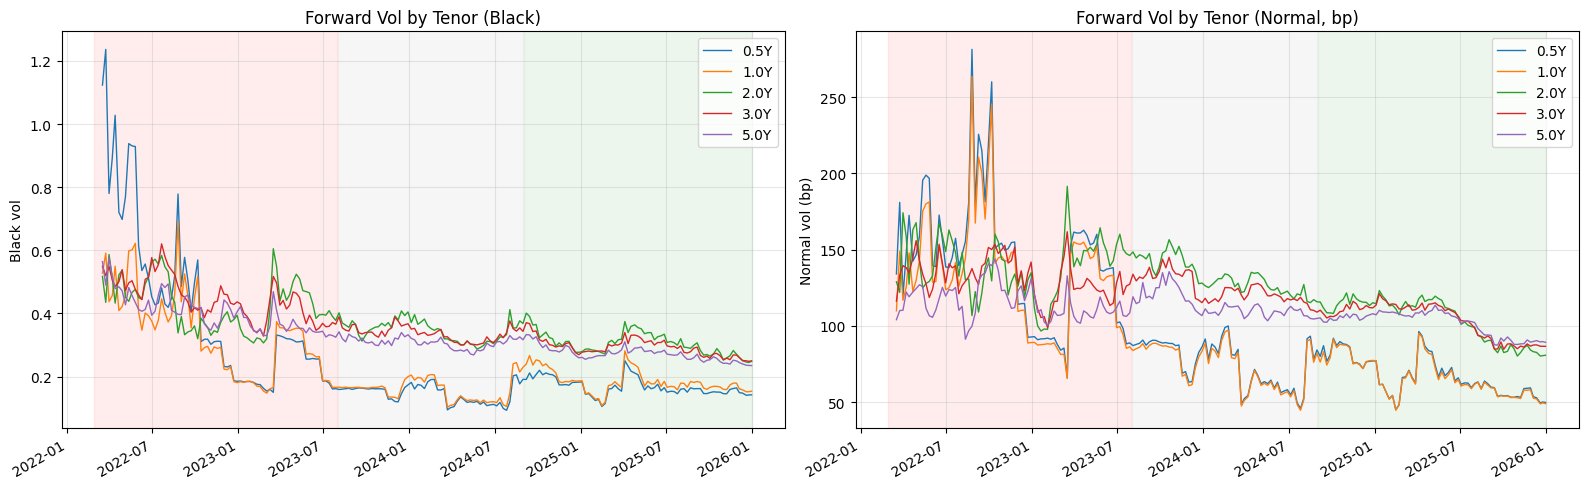

In [6]:
REGIMES = [
    (pd.Timestamp("2022-03-01"), pd.Timestamp("2023-07-31"), "red", "Hiking"),
    (pd.Timestamp("2023-08-01"), pd.Timestamp("2024-08-31"), "gray", "Pause"),
    (pd.Timestamp("2024-09-01"), pd.Timestamp("2025-12-31"), "green", "Easing"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for tenor in KEY_TENORS:
    fwd_vol_black[tenor].dropna().plot(ax=ax, label=f"{tenor}Y", linewidth=1)
ax.set_title("Forward Vol by Tenor (Black)")
ax.set_ylabel("Black vol")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for tenor in KEY_TENORS:
    fwd_vol_normal[tenor].dropna().plot(ax=ax, label=f"{tenor}Y", linewidth=1)
ax.set_title("Forward Vol by Tenor (Normal, bp)")
ax.set_ylabel("Normal vol (bp)")
ax.legend()
ax.grid(True, alpha=0.3)

for a in axes:
    for start, end, color, label in REGIMES:
        a.axvspan(start, end, alpha=0.07, color=color)

plt.tight_layout()
plt.show()

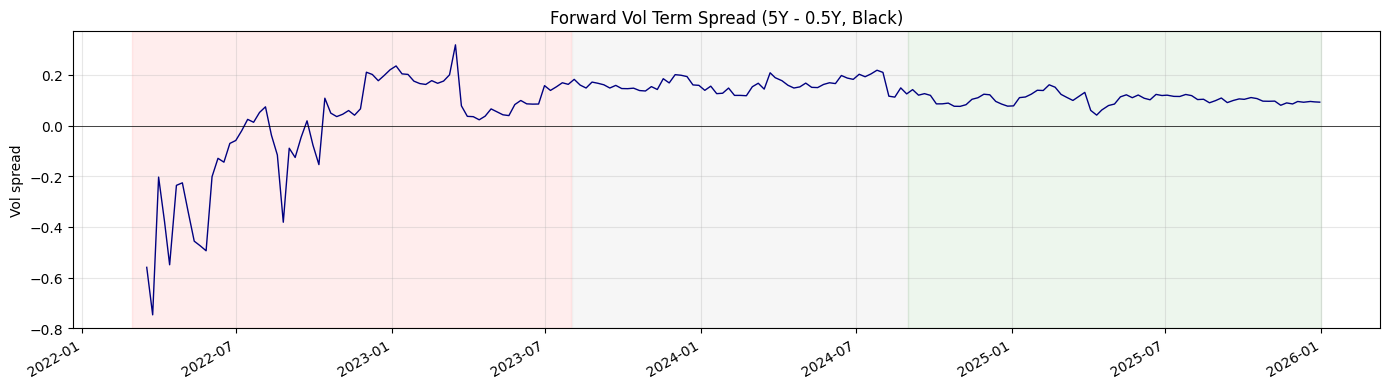

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))

spread_black = fwd_vol_black[5.0] - fwd_vol_black[0.5]
spread_black.dropna().plot(ax=ax, color="navy", linewidth=1)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Forward Vol Term Spread (5Y - 0.5Y, Black)")
ax.set_ylabel("Vol spread")
ax.grid(True, alpha=0.3)

for start, end, color, label in REGIMES:
    ax.axvspan(start, end, alpha=0.07, color=color)

plt.tight_layout()
plt.show()

**Discussion (Q2b):**

**Which tenors are most volatile?** Short-tenor forward vols (0.5Y, 1Y) are far more volatile than long-tenor vols. In normal vol terms, 0.5Y has std = 43.8 bp with a range of 44--278 bp, while 5Y has std = 11.4 bp and ranges only 86--144 bp. This is amplified in Black vol space: 0.5Y Black vol std = 0.20 vs 5Y std = 0.07, partly because Black vol also absorbs the changing rate level.

**Hiking (2022--23):** Short-tenor forward vols are elevated and highly volatile -- 0.5Y normal vol averages 141 bp, peaking near 278 bp. The forward vol curve is inverted or flat: with rates moving 50--75 bp per FOMC meeting, near-term rate uncertainty dominated. The 5Y--0.5Y spread is negative through most of this regime.

**Pause (2023--24):** A sharp regime change. Short-tenor vol collapses (0.5Y drops to 74 bp mean) as rates stabilize near 5.3%, but 2Y and 3Y vol stays elevated (132 and 124 bp) -- the market priced significant uncertainty about the timing and pace of future cuts. The term spread flips strongly positive as the forward vol curve steepens.

**Easing (2024--25):** Short-tenor vol remains low (0.5Y = 66 bp) despite rate cuts beginning, since the cutting path was well-communicated. Longer-tenor vols also decline (2Y = 104 bp, 5Y = 100 bp) as uncertainty about the terminal rate narrows. The forward vol curve is upward-sloping throughout.

## (c) Summary Statistics

In [8]:
print("Forward Vol Summary Statistics (Normal Vol, bp)")
print("=" * 60)
stats_normal = fwd_vol_normal.describe().loc[["mean", "std", "min", "max", "count"]]
display(stats_normal.round(1))

print()
print("Forward Vol Summary Statistics (Black Vol)")
print("=" * 60)
stats_black = fwd_vol_black.describe().loc[["mean", "std", "min", "max", "count"]]
display(stats_black.round(4))

Forward Vol Summary Statistics (Normal Vol, bp)


tenor,0.5,1.0,2.0,3.0,5.0
mean,97.2,92.9,125.0,119.8,110.1
std,44.4,39.8,21.7,16.7,11.0
min,45.0,44.7,80.2,84.7,87.4
max,281.4,263.7,191.6,161.7,143.9
count,199.0,199.0,199.0,199.0,199.0



Forward Vol Summary Statistics (Black Vol)


tenor,0.5,1.0,2.0,3.0,5.0
mean,0.2511,0.2317,0.3613,0.3613,0.3294
std,0.1997,0.1159,0.0770,0.0811,0.0687
min,0.0932,0.1028,0.2446,0.2483,0.2348
max,1.2366,0.6902,0.6052,0.6205,0.5770
count,199.0000,199.0000,199.0000,199.0000,199.0000


In [9]:
def assign_regime(date):
    if date < pd.Timestamp("2023-08-01"):
        return "Hiking"
    elif date < pd.Timestamp("2024-09-01"):
        return "Pause"
    else:
        return "Easing"


regimes = fwd_vol_normal.index.map(assign_regime)

print("Mean Forward Normal Vol (bp) by Regime")
print("=" * 60)
regime_means = fwd_vol_normal.groupby(regimes).mean()
display(regime_means.round(1))

Mean Forward Normal Vol (bp) by Regime


tenor,0.5,1.0,2.0,3.0,5.0
Easing,67.3,66.4,104.4,103.7,101.7
Hiking,143.3,133.6,139.1,131.6,115.3
Pause,75.8,73.8,132.3,124.5,113.7


**Discussion (Q2c):**

We report in **normal vol** (bp) for cross-tenor comparison. The choice matters: in Black vol, the 0.5Y forward vol appears lower on average (0.25) than 2Y (0.36), but in normal vol the ordering reverses -- 0.5Y averages 96 bp vs 2Y at 125 bp. The discrepancy arises because Black vol scales inversely with the forward rate level. During the hiking regime, 0.5Y forward rates were low (~1--3%) while 2Y forwards were higher (~3--4%), mechanically inflating 0.5Y Black vol. Normal vol removes this level effect, revealing that actual rate uncertainty (in absolute bp terms) was genuinely highest at short tenors during the hiking period and highest at intermediate tenors during the pause.

The full-sample means show an upward-sloping normal vol term structure at 2Y+ (104--125 bp), but this masks regime variation: during hiking, the curve was inverted (0.5Y = 141 bp > 5Y = 115 bp), while during easing it slopes upward monotonically (66 to 100 bp). The standard deviation declines sharply with tenor (44 bp at 0.5Y vs 11 bp at 5Y), confirming that short-term policy uncertainty drives the bulk of forward vol variation.